In [ ]:
#Lab 2.4 KNN

In [ ]:
#Preparacion

In [2]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

dataset = pd.read_csv('breast_cancer.csv')

dataset

,mean.radius,mean.texture,mean.perimeter,mean.area,mean.smoothness,mean.compactness,mean.concavity,mean.concave.points,mean.symmetry,mean.fractal.dimension,...,worst.texture,worst.perimeter,worst.area,worst.smoothness,worst.compactness,worst.concavity,worst.concave.points,worst.symmetry,worst.fractal.dimension,cancer
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [3]:
dataset["cancer"].value_counts()

cancer
1    357
0    212
Name: count, dtype: int64

In [5]:
num_y = dataset["cancer"].value_counts()

min_num = min(num_y)

min_class = num_y[num_y == min(num_y)].index[0]

undersamp = dataset[dataset["cancer"] != min_class].sample(min_num, random_state=10)

dataset = pd.concat([undersamp, dataset[dataset["cancer"] == min_class]], axis=0)

dataset["cancer"].value_counts()

cancer
1    212
0    212
Name: count, dtype: int64

In [7]:
x_data = dataset.drop(['cancer'], axis=1)
y_data = dataset["cancer"]

scaler = MinMaxScaler()
scaler.fit(x_data)

x_data = scaler.transform(x_data)

In [ ]:
#Separacion de datos

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

x_train, x_test, y_train, y_test = train_test_split(
    x_data,
    y_data,
    train_size=0.8,
    random_state=14
)

In [ ]:
#Entrenamiento de modelo

Text(0, 0.5, 'Accuracy Score')

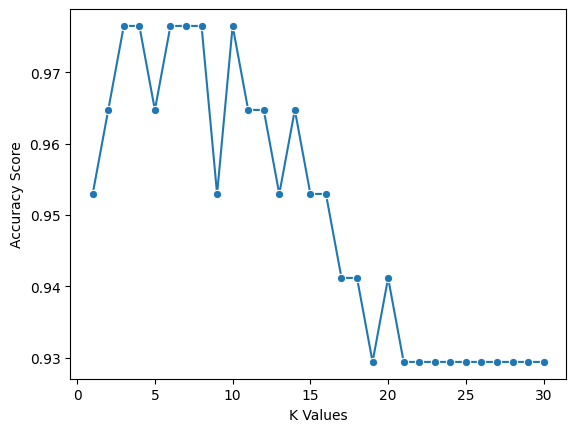

In [10]:
from sklearn.metrics import accuracy_score

k_values = [i for i in range(1, 31)]
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="manhattan")
    knn.fit(x_train, y_train)
    score = accuracy_score(y_test, knn.predict(x_test), normalize=True)
    scores.append(np.mean(score))

sns.lineplot(x=k_values, y=scores, marker='o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")

In [11]:
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(x_train, y_train)

print(accuracy_score(y_train, classifier.predict(x_train), normalize=True))
print(accuracy_score(y_test, classifier.predict(x_test), normalize=True))

0.9646017699115044
0.9764705882352941


In [ ]:
#Evaluacion de resultados

In [15]:
!pip install mlxtend

0.9764705882352941

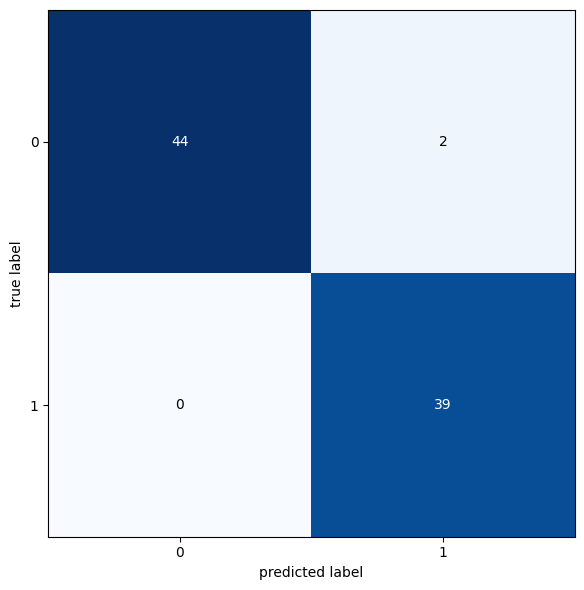

In [16]:
from mlxtend.plotting import plot_confusion_matrix

y_pred = classifier.predict(x_test)

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(conf_mat=cm, figsize=(6, 6), show_normed=False)
plt.tight_layout()

accuracy_score(y_test, y_pred)

In [17]:
print(classification_report(y_test, round(pd.Series(classifier.predict(x_test)))))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        46
           1       0.95      1.00      0.97        39

    accuracy                           0.98        85
   macro avg       0.98      0.98      0.98        85
weighted avg       0.98      0.98      0.98        85



AUC: 0.986


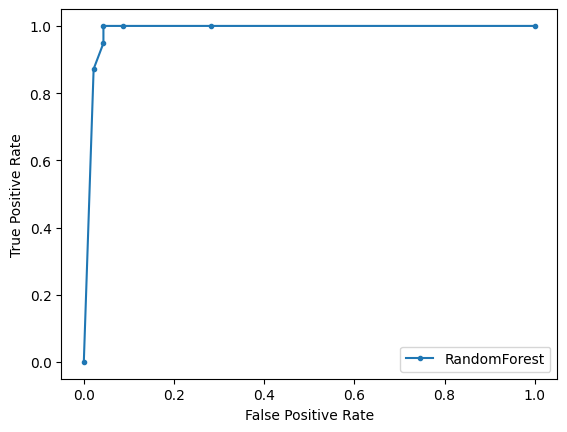

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib import pyplot

auc = roc_auc_score(y_test, classifier.predict_proba(x_test)[:, 1])
print('AUC: %.3f' % auc)

fpr, tpr, _ = roc_curve(y_test, classifier.predict_proba(x_test)[:, 1])

# plot the roc curve for the model
pyplot.plot(fpr, tpr, marker='.', label='RandomForest')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')

# show the legend
pyplot.legend()

# show the plot
pyplot.show()